# 回归与标准误教程

### 系数只是一半，另一半是你有多确定

跑一个回归很容易。难的是回答下一个问题，这个系数有多可靠。标准误、t 统计量、置信区间、显著性星号，全都取决于你对误差项做了什么假设。假设错了，系数不变，推断全错。

本教程用模拟实验把三种最常见的情形演示清楚。误差方差不相等时该怎么办，同一组内的观测彼此相关时该怎么办，聚类个数很少时又该怎么办。每一种情形都先看「用错了会怎样」，再看正确的做法。全程离线。

| 节 | 内容 | 你会学到 |
| --- | --- | --- |
| 1 | 一个基准回归 | `sp.regress` 的结果怎么读 |
| 2 | 标准误到底在估计什么 | 抽样分布的标准差，用模拟直接看 |
| 3 | 异方差 | 经典标准误何时失效，HC0 到 HC3 的区别 |
| 4 | 聚类 | 组内相关使有效样本量远小于名义样本量 |
| 5 | 在哪一层聚类 | 一条实用规则 |
| 6 | 聚类个数很少 | 聚类稳健标准误也会失效，wild bootstrap 与 CR2 |
| 7 | 检验多个系数 | `sp.test` 和 `sp.lincom` |
| 8 | 导出回归表 | `sp.regtable` |
| 9 | 小结 | 一份清单 |

In [1]:
import warnings

warnings.filterwarnings("ignore")  # 教程里隐藏无关提示，正式分析时建议保留

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statspai as sp

plt.rcParams["figure.dpi"] = 80
pd.set_option("display.width", 120)
print("StatsPAI 版本:", sp.__version__)

StatsPAI 版本: 1.39.2


## 1. 一个基准回归

用 Card (1995) 的工资数据跑一个 Mincer 工资方程。公式的写法与 R 相同，波浪线左边是被解释变量，右边的解释变量用加号连接，常数项自动加入。

In [2]:
card = sp.datasets.card_1995()
formula = "lwage ~ educ + exper + expersq + black + south + smsa"

ols = sp.regress(formula, data=card)
print(ols.summary())

Model: OLS
Method: Least Squares
Dependent Variable: lwage
           Coefficient  Std. Error  t-statistic  P>|t|  [0.025  0.975]
Intercept       4.7337      0.0676      70.0219 0.0000  4.6011  4.8662
educ            0.0740      0.0035      21.1126 0.0000  0.0671  0.0809
exper           0.0836      0.0066      12.5750 0.0000  0.0706  0.0966
expersq        -0.0022      0.0003      -7.0503 0.0000 -0.0029 -0.0016
black          -0.1896      0.0176     -10.7583 0.0000 -0.2242 -0.1551
south          -0.1249      0.0151      -8.2590 0.0000 -0.1545 -0.0952
smsa            0.1614      0.0156      10.3654 0.0000  0.1309  0.1920

Model Diagnostics:
--------------------
R-squared           : 0.2905
Adj. R-squared      : 0.2891
F-statistic         : 204.9318
Prob (F-statistic)  : 0.0000
Log-Likelihood      : -1308.7016
AIC                 : 2631.4031
BIC                 : 2673.4710


结果对象的常用属性如下。

In [3]:
print("educ 的系数    :", round(ols.params["educ"], 5))
print("educ 的标准误  :", round(ols.std_errors["educ"], 5))
print("educ 的 t 值   :", round(ols.tvalues["educ"], 2))
print("educ 的 p 值   :", f"{ols.pvalues['educ']:.2e}")
print("R²             :", round(ols.r2, 4))
print("观测数         :", ols.n_obs)

ols.tidy().round(4)   # 一张整洁的系数表，方便后续处理

educ 的系数    : 0.07401
educ 的标准误  : 0.00351
educ 的 t 值   : 21.11
educ 的 p 值   : 2.28e-92
R²             : 0.2905
观测数         : 3010


,term,estimate,std_error,statistic,p_value,conf_low,conf_high
0,Intercept,4.7337,0.0676,70.0219,0.0,4.6011,4.8662
1,educ,0.0740,0.0035,21.1126,0.0,0.0671,0.0809
2,exper,0.0836,0.0066,12.5750,0.0,0.0706,0.0966
3,expersq,-0.0022,0.0003,-7.0503,0.0,-0.0029,-0.0016
4,black,-0.1896,0.0176,-10.7583,0.0,-0.2242,-0.1551
5,south,-0.1249,0.0151,-8.2590,0.0,-0.1545,-0.0952
6,smsa,0.1614,0.0156,10.3654,0.0,0.1309,0.1920


教育年限的系数是 0.074，多读一年书对应的工资高 7.4%。这是条件相关，不一定是因果效应，因果解释的问题在工具变量那份教程里讨论。本教程只关心第二列，标准误 0.0035 是怎么来的，它可不可信。

上面没有指定 `robust=`，用的是**经典标准误**。它假设误差项独立，并且方差对所有观测都相同（同方差）。下面看这两个假设各自失效时会发生什么。

## 2. 标准误到底在估计什么

想象把同一项研究重复做很多次，每次抽一个新样本，得到一个新的 $\hat\beta$。这些 $\hat\beta$ 的标准差就是它的**抽样标准差**。标准误是用手里这一个样本对它的估计。

现实里只有一个样本，抽样标准差看不到。模拟里可以。于是有了检验标准误的办法。

1. 设定一个数据生成过程，重复抽样很多次。
2. 每次记录 $\hat\beta$ 和报告的标准误。
3. 比较「$\hat\beta$ 的实际标准差」和「标准误的平均值」。两者应该接近。
4. 当真实系数为 0 时，名义 5% 的检验应该恰好拒绝 5% 的次数。

第 4 条叫**拒绝率**或检验水平（size）。它高于 5%，说明标准误偏小，你会过于频繁地宣称发现了并不存在的效应。

## 3. 异方差

下面的数据里 $x$ 对 $y$ 没有任何影响，真实系数为 0。误差的标准差随 $|x|$ 增大，这就是异方差。收入数据里很常见，高收入者的收入波动通常更大。

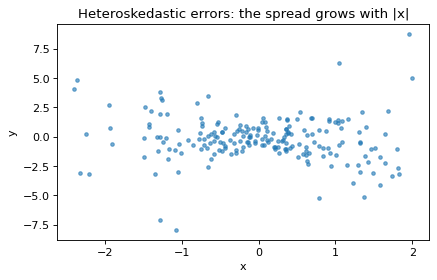

In [4]:
def heteroskedastic_sample(rng, n=200):
    x = rng.normal(size=n)
    u = rng.normal(size=n) * (0.5 + 1.5 * np.abs(x))   # 误差的标准差随 |x| 增大
    return pd.DataFrame({"x": x, "y": 0.0 * x + u})


rng = np.random.default_rng(0)
one = heteroskedastic_sample(rng)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.scatter(one["x"], one["y"], s=10, alpha=0.6)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Heteroskedastic errors: the spread grows with |x|")
plt.show()

In [5]:
reps = 1000
rng = np.random.default_rng(1)
records = []
for _ in range(reps):
    sample = heteroskedastic_sample(rng)
    row = {}
    for kind in ("nonrobust", "hc1", "hc3"):
        fit = sp.regress("y ~ x", data=sample, robust=kind)
        row["beta"] = fit.params["x"]
        row[f"se_{kind}"] = fit.std_errors["x"]
        row[f"reject_{kind}"] = fit.pvalues["x"] < 0.05
    records.append(row)
mc = pd.DataFrame(records)

print(f"系数估计值的实际标准差: {mc['beta'].std():.4f}\n")
pd.DataFrame({
    "mean reported SE": [mc[f"se_{k}"].mean() for k in ("nonrobust", "hc1", "hc3")],
    "rejection rate at 5%": [mc[f"reject_{k}"].mean() for k in ("nonrobust", "hc1", "hc3")],
}, index=["classical", "HC1 (robust)", "HC3"]).round(4)

系数估计值的实际标准差: 0.2136



,mean reported SE,rejection rate at 5%
classical,0.1356,0.212
HC1 (robust),0.2125,0.051
HC3,0.2174,0.046


系数本身是无偏的，异方差不影响这一点。出问题的是标准误。

- 经典标准误的平均值只有系数实际标准差的六成多。真实系数为 0，它却在 21% 的模拟里宣称显著，是名义水平的四倍。
- 稳健标准误接近实际标准差，拒绝率回到 5% 附近。

这类稳健标准误由 White (1980) 提出，也叫 Huber-White 或三明治标准误。它不假设误差方差相同，用每个观测自己的残差平方来估计方差。

### HC0 到 HC3

稳健标准误有几个小样本修正的版本。

| `robust=` | 修正方式 | 对应 |
| --- | --- | --- |
| `"hc0"` | 无修正 | White 的原始形式 |
| `"hc1"` | 乘以 $n/(n-k)$ | Stata 的 `, robust` |
| `"hc2"` | 残差平方除以 $1-h_{ii}$ | |
| `"hc3"` | 残差平方除以 $(1-h_{ii})^2$ | R `sandwich::vcovHC` 的默认 |

其中 $h_{ii}$ 是杠杆值。样本大的时候四者几乎没有差别。样本小或者存在高杠杆点时，HC3 更保守，通常也更可靠。

In [6]:
pd.Series(
    {kind: sp.regress(formula, data=card, robust=kind).std_errors["educ"]
     for kind in ("nonrobust", "hc0", "hc1", "hc2", "hc3")},
    name="se(educ)",
).round(6)

nonrobust    0.003505
hc0          0.003638
hc1          0.003642
hc2          0.003643
hc3          0.003648
Name: se(educ), dtype: float64

在 3,010 个观测的工资数据上，四种稳健标准误在第四位小数上才有差别，都比经典标准误略大。

**实用建议**。横截面数据默认使用稳健标准误。同方差成立时它和经典标准误差不多，不成立时只有它是对的，代价很小。

## 4. 聚类

稳健标准误仍然假设观测之间相互独立。很多数据不满足这一点。同一个班级的学生，同一个州不同年份的观测，同一家公司的员工，它们的误差项往往相关。

相关的观测提供的信息少于同样数量的独立观测。50 个学生来自同一个班，他们共享同一位老师、同一间教室，信息量远不如来自 50 个班的 50 个学生。忽略这一点，标准误会严重偏小。

下面的模拟把这个问题放到最大。20 个组，每组 50 人。解释变量 $x$ **只在组的层面变化**（比如一项按班级实施的政策），误差项里有一个组内共享的成分。真实系数仍然为 0。

In [7]:
def clustered_sample(rng, n_groups=20, group_size=50):
    g = np.repeat(np.arange(n_groups), group_size)
    x = np.repeat(rng.normal(size=n_groups), group_size)              # 组层面的解释变量
    u = np.repeat(rng.normal(size=n_groups), group_size) + rng.normal(size=n_groups * group_size)
    return pd.DataFrame({"g": g, "x": x, "y": 0.0 * x + u})


def run_cluster_mc(n_groups, reps=500, seed=2):
    rng = np.random.default_rng(seed)
    records = []
    for _ in range(reps):
        sample = clustered_sample(rng, n_groups=n_groups)
        fits = {
            "classical": sp.regress("y ~ x", data=sample),
            "robust": sp.regress("y ~ x", data=sample, robust="hc1"),
            "cluster": sp.regress("y ~ x", data=sample, cluster="g"),
        }
        row = {"beta": fits["cluster"].params["x"]}
        for name, fit in fits.items():
            row[f"se_{name}"] = fit.std_errors["x"]
            row[f"reject_{name}"] = fit.pvalues["x"] < 0.05
        records.append(row)
    out = pd.DataFrame(records)
    table = pd.DataFrame({
        "mean reported SE": [out[f"se_{k}"].mean() for k in fits],
        "rejection rate at 5%": [out[f"reject_{k}"].mean() for k in fits],
    }, index=list(fits))
    return out["beta"].std(), table


sd_beta, table20 = run_cluster_mc(n_groups=20)
print(f"20 个组，每组 50 人，共 1,000 个观测。系数估计值的实际标准差: {sd_beta:.3f}\n")
table20.round(3)

20 个组，每组 50 人，共 1,000 个观测。系数估计值的实际标准差: 0.254



,mean reported SE,rejection rate at 5%
classical,0.047,0.704
robust,0.045,0.708
cluster,0.215,0.100


这张表值得多看一会儿。

- 经典标准误和稳健标准误都只有实际标准差的几分之一。真实效应为 0，它们却在大部分模拟里报告「显著」。
- 聚类标准误接近实际标准差，拒绝率从 70% 降到 10%。这仍然是名义水平的两倍，原因在第 6 节。

稳健标准误在这里完全没有帮助。它处理的是方差不相等，而这里的问题是观测之间相关。**名义上有 1,000 个观测，真正独立的信息只有 20 份**。

`cluster="g"` 告诉 `sp.regress` 误差在 `g` 定义的组内可以任意相关，组与组之间独立。相当于 Stata 的 `vce(cluster g)`。

## 5. 在哪一层聚类

聚类该设在哪一层，是实证研究里最常被问到的问题之一。几条实用的规则如下。

1. **处理变量在哪一层分配，就至少在那一层聚类**。政策按州实施，就按州聚类，哪怕数据是个人层面的。
2. **面板数据按个体聚类**，允许同一个体不同时期的误差相关。
3. **拿不准时选更高的层级**。聚得太细会低估标准误。聚得粗一些通常只是略保守，前提是聚类个数还够多。
4. **固定效应不能代替聚类**。加入州固定效应去掉的是州的平均水平，州内各年份误差之间的相关仍然存在。

第 4 条经常被误解，用一个例子说明。下面的面板里每个单位的误差有持续性（一阶自回归）。加入单位固定效应之后，再比较聚类与不聚类的标准误。

In [8]:
rng = np.random.default_rng(3)
n_units, n_periods = 50, 20
unit = np.repeat(np.arange(n_units), n_periods)
period = np.tile(np.arange(n_periods), n_units)

# 处理从第 10 期开始，对一半单位生效。真实效应为 0
treated_unit = np.repeat(rng.integers(0, 2, n_units), n_periods)
d = treated_unit * (period >= 10)

# 每个单位的误差是 AR(1)，相关系数 0.8
e = np.zeros((n_units, n_periods))
e[:, 0] = rng.normal(size=n_units)
for t in range(1, n_periods):
    e[:, t] = 0.8 * e[:, t - 1] + rng.normal(size=n_units) * 0.6
panel = pd.DataFrame({"unit": unit, "period": period, "d": d, "y": e.ravel()})

fe_plain = sp.hdfe_ols("y ~ d | unit + period", data=panel)
fe_cluster = sp.hdfe_ols("y ~ d | unit + period", data=panel, cluster="unit")

print(f"双向固定效应，不聚类 : 系数 {fe_plain.params['d']:.3f}   se {fe_plain.std_errors['d']:.3f}")
print(f"双向固定效应，按单位聚类: 系数 {fe_cluster.params['d']:.3f}   se {fe_cluster.std_errors['d']:.3f}")

双向固定效应，不聚类 : 系数 0.075   se 0.101
双向固定效应，按单位聚类: 系数 0.075   se 0.250


系数相同，按单位聚类之后标准误大了一倍以上。固定效应已经在模型里，序列相关仍然让不聚类的标准误严重偏小。这正是 DID 研究必须按处理分配的单位聚类的原因。

处理变量如果同时在两个维度上相关（比如公司和年份），可以用双向聚类，`sp.hdfe_ols(..., cluster=["firm", "year"])`。

## 6. 聚类个数很少

聚类稳健标准误的理论依据是聚类个数趋于无穷。只有十几个甚至几个聚类时，它会系统性地偏小。第 4 节 20 个组时拒绝率已经是 10%。把组数减到 8 个再看。

In [9]:
sd_beta8, table8 = run_cluster_mc(n_groups=8)
print(f"8 个组，每组 50 人。系数估计值的实际标准差: {sd_beta8:.3f}\n")
table8.round(3)

8 个组，每组 50 人。系数估计值的实际标准差: 0.436



,mean reported SE,rejection rate at 5%
classical,0.077,0.740
robust,0.073,0.746
cluster,0.316,0.142


只有 8 个组时，聚类标准误的拒绝率升到 14%。它比不聚类好得多，但仍然不够。

文献里有两类常用的补救办法。

**Wild cluster bootstrap**（Cameron, Gelbach and Miller 2008）。在原假设成立的前提下，对每个聚类的残差整体随机翻转符号，生成大量虚拟样本，用 t 统计量在这些样本中的分布来计算 p 值。它在聚类很少时的表现比渐近近似好得多。

**CR2 修正**（Bell and McCaffrey 2002）。类似于 HC2，对聚类层面的残差做杠杆调整，并配合调整后的自由度。

下面取一份 8 个组的样本，把几种推断方法放在一起。

In [10]:
rng = np.random.default_rng(11)
few = clustered_sample(rng, n_groups=8)

conventional = sp.regress("y ~ x", data=few, cluster="g")
cr2 = sp.regress("y ~ x", data=few, cluster="g", vce="cr2")
wild = sp.wild_cluster_bootstrap(
    few, y="y", x=["x"], cluster="g", test_var="x", n_boot=999, weight_type="webb", seed=0
)

print(f"系数估计: {conventional.params['x']:.3f}   (真实值为 0)\n")
pd.DataFrame({
    "se": [conventional.std_errors["x"], cr2.std_errors["x"], np.nan],
    "p-value": [conventional.pvalues["x"], cr2.pvalues["x"], wild["p_boot"]],
}, index=["cluster-robust", "CR2", "wild cluster bootstrap"]).round(3)

系数估计: -0.199   (真实值为 0)



,se,p-value
cluster-robust,0.725,0.791
CR2,0.887,0.829
wild cluster bootstrap,NaN,0.720


聚类少于 12 个左右时，建议把默认的 Rademacher 权重（只取 ±1）换成 Webb (2014) 的六点分布，上面已经这样做了。8 个聚类下 ±1 的组合只有 256 种，p 值能取到的值太少。

wild bootstrap 的置信区间应该用**检验反演**得到，也就是找出所有不被拒绝的原假设值。`sp.wild_cluster_ci_inv` 做的是这件事，对应 Stata `boottest` 报告的区间。

In [11]:
ci_inv = sp.wild_cluster_ci_inv(few, y="y", x=["x"], cluster="g", test_var="x", n_boot=999, seed=0)
print(f"检验反演的 95% 置信区间: [{ci_inv['ci'][0]:.2f}, {ci_inv['ci'][1]:.2f}]   (聚类稳健区间的半宽约为 {1.96 * ci_inv['se_cluster']:.2f})")

检验反演的 95% 置信区间: [-1.74, 1.30]   (聚类稳健区间的半宽约为 1.42)


单独一份样本说明不了方法的好坏，要看重复抽样下的拒绝率。下面对 8 个组的设计各跑 300 次模拟。wild bootstrap 每次要重抽 399 次，这个单元格需要一分钟左右。

In [12]:
rng = np.random.default_rng(5)
reps = 300
rejections = {"cluster-robust": 0, "CR2": 0, "wild cluster bootstrap": 0}
for i in range(reps):
    sample = clustered_sample(rng, n_groups=8)
    rejections["cluster-robust"] += sp.regress("y ~ x", data=sample, cluster="g").pvalues["x"] < 0.05
    rejections["CR2"] += sp.regress("y ~ x", data=sample, cluster="g", vce="cr2").pvalues["x"] < 0.05
    boot = sp.wild_cluster_bootstrap(
        sample, y="y", x=["x"], cluster="g", test_var="x", n_boot=399, weight_type="webb", seed=i
    )
    rejections["wild cluster bootstrap"] += boot["p_boot"] < 0.05

pd.Series({k: v / reps for k, v in rejections.items()}, name="rejection rate at 5% (8 clusters)").round(3)

cluster-robust            0.153
CR2                       0.080
wild cluster bootstrap    0.043
Name: rejection rate at 5% (8 clusters), dtype: float64

wild bootstrap 的拒绝率回到了 5% 附近。CR2 把拒绝率从 15% 降到 8%，改善明显，但在这个设计里仍然偏高。300 次模拟的拒绝率本身有大约 ±0.025 的抽样误差，所以不必纠结小数点后第二位。

**实用建议**。聚类个数少于 40 左右时，报告 wild cluster bootstrap 的 p 值和检验反演的置信区间，CR2 标准误可以作为补充。处理组只有一两个聚类的情形更棘手，这两种方法也可能失效，需要专门的方法（`sp.did_few_treated`）。

## 7. 检验多个系数

单个系数是否为 0 看 t 检验就够了。涉及多个系数的假设要用联合检验。`sp.test` 相当于 Stata 的 `test`，`sp.lincom` 相当于 `lincom`。它们使用回归时指定的那一套标准误。

In [13]:
ols_r = sp.regress(formula, data=card, robust="hc1")

# 经验的两项是否联合显著
joint = sp.test(ols_r, "exper = 0, expersq = 0")
print(f"H0: exper = expersq = 0     F{joint['df']} = {joint['statistic']:.1f},  p = {joint['pvalue']:.2e}")

# 两个系数是否相等
equal = sp.test(ols_r, "black = south")
print(f"H0: black = south           F{equal['df']} = {equal['statistic']:.2f},  p = {equal['pvalue']:.4f}")

H0: exper = expersq = 0     F(2, 3003) = 178.3,  p = 6.82e-74
H0: black = south           F(1, 3003) = 5.91,  p = 0.0151


In [14]:
# 工作经验为 10 年时，再多一年经验的边际回报是 exper + 2*10*expersq
marginal = sp.lincom(ols_r, "exper + 20*expersq")
print(f"经验为 10 年时的边际回报: {marginal['estimate']:.4f}  (se {marginal['se']:.4f})")
print(f"95% 置信区间: [{marginal['ci'][0]:.4f}, {marginal['ci'][1]:.4f}]")

经验为 10 年时的边际回报: 0.0388  (se 0.0022)
95% 置信区间: [0.0344, 0.0431]


`exper` 和 `expersq` 单独看各有一个 t 值，但「经验对工资有没有影响」是关于两个系数的联合假设，要用 F 检验回答。

系数的线性组合也有自己的标准误，它取决于系数之间的协方差，不能用两个标准误简单相加。`sp.lincom` 会用完整的协方差矩阵算出来。

## 8. 导出回归表

论文里通常把几个模型并排放在一张表里。`sp.regtable` 相当于 Stata 的 `esttab` 或 `outreg2`，R 的 `modelsummary`。

In [15]:
m1 = sp.regress("lwage ~ educ", data=card, robust="hc1")
m2 = sp.regress("lwage ~ educ + exper + expersq", data=card, robust="hc1")
m3 = sp.regress(formula, data=card, robust="hc1")

table = sp.regtable(m1, m2, m3, model_labels=["(1)", "(2)", "(3)"])
print(table)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                             (1)           (2)           (3)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Intercept               5.571***      4.469***      4.734***
                         (0.039)       (0.070)       (0.070)

educ                   0.0521***     0.0932***     0.0740***
                        (0.0029)      (0.0037)      (0.0036)

exper                                0.0898***     0.0836***
                                      (0.0071)      (0.0067)

expersq                            -0.00249***   -0.00224***
                                     (0.00034)     (0.00032)

black                                              -0.190***
                                                     (0.017)

south                                              -0.125***
                                                     (0.015)

smsa                                                0.161***
              

同一个表格对象可以直接导出到 Word、Excel 或 LaTeX。

```python
table.to_word("table1.docx")
table.to_excel("table1.xlsx")
table.to_latex("table1.tex")
```

表格下方应该注明标准误的类型。读者看到括号里的数字时，需要知道它是经典的、稳健的，还是聚类的，以及在哪一层聚类。

## 9. 小结

| 数据的情形 | 该用什么 | `sp.regress` 的写法 |
| --- | --- | --- |
| 横截面，观测独立 | 异方差稳健标准误 | `robust="hc1"`，小样本用 `"hc3"` |
| 观测在组内相关 | 聚类稳健标准误 | `cluster="组变量"` |
| 面板数据 | 按个体聚类 | `cluster="个体变量"` |
| 处理按组分配 | 按分配的层级聚类 | `cluster="分配层级"` |
| 聚类个数少（少于 40 左右） | wild cluster bootstrap 或 CR2 | `sp.wild_cluster_bootstrap`，`vce="cr2"` |
| 两个维度上都相关 | 双向聚类 | `sp.hdfe_ols(..., cluster=["a", "b"])` |

记住三件事。

1. **标准误的选择不改变系数**，只改变你对系数有多确定。
2. **固定效应不能代替聚类**。
3. **拿不准的时候做模拟**。把你的数据结构搬进一个真实效应为 0 的模拟里，看名义 5% 的检验实际拒绝多少次。本教程的每一个结论都是这样得到的。

### 本教程用到的方法的文献

下面的 BibTeX 条目直接取自 StatsPAI 核验过的 `paper.bib`。

In [16]:
keys = [
    "white1980heteroskedasticity",
    "liang1986longitudinal",
    "cameron2008bootstrap",
    "bell2002bias",
    "cameron2015practitioner",
    "mackinnon2023cluster",
]
print(sp.bibtex(keys))

@article{white1980heteroskedasticity,
  title={A Heteroskedasticity-Consistent Covariance Matrix Estimator and a Direct Test for Heteroskedasticity},
  author={White, Halbert},
  journal={Econometrica},
  year={1980},
  doi={10.2307/1912934}
}

@article{liang1986longitudinal,
  title={Longitudinal data analysis using generalized linear models},
  author={LIANG, KUNG-YEE and ZEGER, SCOTT L.},
  journal={Biometrika},
  volume={73},
  number={1},
  pages={13--22},
  year={1986},
  doi={10.1093/biomet/73.1.13}
}

@article{cameron2008bootstrap,
  title={Bootstrap-Based Improvements for Inference with Clustered Errors},
  author={Cameron, A. Colin and Gelbach, Jonah B. and Miller, Douglas L.},
  journal={Review of Economics and Statistics},
  volume={90},
  number={3},
  pages={414--427},
  year={2008},
  doi={10.1162/rest.90.3.414}
}

@article{bell2002bias,
  title={Bias Reduction in Standard Errors for Linear Regression with Multi-Stage Samples},
  author={Bell, Robert M. and McCaffrey, Da